
# GoC MA2024 Convergence Analysis

This notebook compares fixed-step convergence for the GoC debug model using a high-resolution NEURON reference.
It reports three error families:

- `neuron_vs_ref`: `NEURON(dt)` compared with `NEURON(ref_dt)`
- `braincell_vs_ref`: `BrainCell(dt)` compared with `NEURON(ref_dt)`
- `braincell_vs_neuron`: `BrainCell(dt)` compared with `NEURON(dt)`

Use `SMOKE_MODE = True` for a fast sanity check. Set it to `False` for the real convergence sweep.


In [1]:

from __future__ import annotations

import os
import sys
import json
from dataclasses import asdict, replace
from pathlib import Path
from typing import Any

# Set these before importing JAX/BrainCell users.
os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import brainstate
import brainunit as u
from neuron import h


def find_repo_root(start: Path | None = None) -> Path:
    cwd = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside the braincell-ion_dyn repository.")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from braincell import mech
from braincell.filter import at
from examples.neuron_compare.cell.goc_ma2020.debug.goc_parameters import (
    GoCConfig,
    GoCToggles,
    load_goc20_params,
    toggles_to_dict,
)
from examples.neuron_compare.cell.goc_ma2020.debug.goc_neuron_debug import GoC as NeuronGoC
from examples.neuron_compare.cell.goc_ma2020.debug.goc_braincell_debug import GoC as BrainCellGoC

brainstate.environ.set(precision=64)
print("repo:", REPO_ROOT)
print("brainstate precision:", brainstate.environ.get('precision'))
try:
    import jax
    import jax.numpy as jnp
    print("jax_enable_x64:", jax.config.read("jax_enable_x64"), "default dtype:", jnp.asarray(0.0).dtype)
except Exception as exc:
    print("jax dtype check failed:", type(exc).__name__, exc)


--No graphics will be displayed.


repo: /home/swl/braincell-ion_dyn
brainstate precision: 64
jax_enable_x64: True default dtype: float64



## Configuration

`REFERENCE_SCOPE = "soma"` is the safest default for very small `REF_DT_MS`. Use `"selected"` to add selected compartments, or `"all"` only for short runs because it records every compartment at the reference time step.


In [2]:
# Fast smoke check by default. Set False for the real convergence experiment.
SMOKE_MODE = False

# Main experiment defaults used when SMOKE_MODE is False.
DURATION_MS = 40.0
DELAY_MS = 5.0
STIM_DUR_MS = 30.0
AMP_NA = 0.2
TEMP_C = 30.0
V_INIT_MV = -65.0
DT_LIST_MS = [0.1, 0.05, 0.025, 0.0125, 0.00625]
REF_DT_MS = 0.001
SPIKE_THRESHOLD_MV = 0.0

# Recording scope: "soma", "selected", or "all".
REFERENCE_SCOPE = "soma"
BRAINCELL_NEURON_SCOPE = "all"
SELECTED_COMPARTMENTS = [
    # Examples:
    # {"branch_index": 0, "local_index": 0},
    # {"branch_name": "dend_0", "local_index": 0},
]

FROZEN_GHK = True
OUTPUT_DIR = Path("examples/neuron_compare/cell/goc_ma2020/debug/results/convergence_analysis")

TOGGLES = GoCToggles(
    leak=True,
    nav=True,
    kv1p1=True,
    kv3p4=True,
    kv4p3=True,
    km=True,
    kca1p1=True,
    kca2p2=True,
    kca3p1=True,
    cahva=True,
    cav2p3=True,
    cav3p1=True,
    hcn1=True,
    hcn2=True,
    cdp=True,
)

if SMOKE_MODE:
    DURATION_MS = 1.0
    DELAY_MS = 0.2
    STIM_DUR_MS = 0.5
    DT_LIST_MS = [0.1, 0.05]
    REF_DT_MS = 0.025
    REFERENCE_SCOPE = "soma"
    BRAINCELL_NEURON_SCOPE = "all"

OUTPUT_DIR = REPO_ROOT / OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("duration ms:", DURATION_MS)
print("dt list:", DT_LIST_MS, "ref:", REF_DT_MS)
print("reference scope:", REFERENCE_SCOPE)
print("braincell_vs_neuron scope:", BRAINCELL_NEURON_SCOPE)
print("spike threshold mV:", SPIKE_THRESHOLD_MV)
print("output:", OUTPUT_DIR)


duration ms: 40.0
dt list: [0.1, 0.05, 0.025, 0.0125, 0.00625] ref: 0.001
reference scope: soma
braincell_vs_neuron scope: all
spike threshold mV: 0.0
output: /home/swl/braincell-ion_dyn/examples/neuron_compare/cell/goc_ma2020/debug/results/convergence_analysis


In [3]:
METRIC_UNITS = {
    "soma_v": "mV",
    "compartment_v": "mV",
    "soma_cai": "mM",
    "spike_time": "ms",
}

ERROR_VALUE_COLUMNS = [
    "max_abs",
    "mean_abs",
    "rmse",
    "mean_of_mean_abs_mV",
    "mean_of_rmse_mV",
    "global_max_abs_mV",
    "mean_abs_spike_time_error_ms",
    "max_abs_spike_time_error_ms",
]


def make_config() -> GoCConfig:
    return GoCConfig(toggles=TOGGLES, temperature_celsius=TEMP_C, v_init_mV=V_INIT_MV)


def _infer_branch_type(sec_name: str) -> str:
    name = sec_name.lower()
    if "soma" in name:
        return "soma"
    if "axon" in name:
        return "axon"
    return "dend"


def nominal_step_time(dt_ms: float, n: int) -> np.ndarray:
    # BrainCell run traces and trimmed NEURON traces represent post-step states.
    return (np.arange(n, dtype=float) + 1.0) * float(dt_ms)


def trim_neuron_time_and_values(time_ms: Any, values: Any, *, dt_ms: float, duration_ms: float) -> tuple[np.ndarray, np.ndarray]:
    t = np.asarray(time_ms, dtype=float).reshape(-1)
    y = np.asarray(values, dtype=float)
    if y.ndim == 1:
        y = y.reshape(-1)
    if t.shape[0] == y.shape[0] and t.shape[0] > 0 and np.isclose(t[0], 0.0):
        t = t[1:]
        y = y[1:] if y.ndim == 1 else y[1:, :]
    if t.shape[0] != (y.shape[0] if y.ndim == 1 else y.shape[0]):
        n = min(t.shape[0], y.shape[0])
        t = t[:n]
        y = y[:n] if y.ndim == 1 else y[:n, :]
    # Guard against h.run() recording one extra endpoint beyond requested comparison range.
    mask = t <= duration_ms + 1e-9
    return t[mask], y[mask] if y.ndim == 1 else y[mask, :]


def quantity_to_numpy(value: Any, metric: str) -> np.ndarray:
    if value is None:
        return np.asarray([], dtype=float)
    if metric in {"soma_v", "compartment_v"}:
        return np.asarray(value.to_decimal(u.mV) if hasattr(value, "to_decimal") else value, dtype=float)
    if metric == "soma_cai":
        return np.asarray(value.to_decimal(u.mM) if hasattr(value, "to_decimal") else value, dtype=float)
    return np.asarray(value, dtype=float)


def selected_table_rows(table: pd.DataFrame, selected: list[dict[str, Any]]) -> pd.DataFrame:
    if not selected:
        return table.iloc[0:0].copy()
    masks = []
    for item in selected:
        mask = pd.Series(True, index=table.index)
        for key, value in item.items():
            if key not in table.columns:
                raise KeyError(f"Unknown selected compartment key {key!r}; columns={list(table.columns)!r}")
            mask &= table[key] == value
        masks.append(mask)
    out = table[np.logical_or.reduce([m.to_numpy() for m in masks])].copy()
    return out.reset_index(drop=True)


def interp_trace(src_t: np.ndarray, src_y: np.ndarray, dst_t: np.ndarray) -> np.ndarray:
    src_t = np.asarray(src_t, dtype=float).reshape(-1)
    src_y = np.asarray(src_y, dtype=float)
    dst_t = np.asarray(dst_t, dtype=float).reshape(-1)
    if src_y.size == 0 or dst_t.size == 0:
        return np.asarray([], dtype=float)
    if src_y.ndim == 1:
        return np.interp(dst_t, src_t, src_y)
    return np.column_stack([np.interp(dst_t, src_t, src_y[:, i]) for i in range(src_y.shape[1])])


def common_time(a_t: np.ndarray, b_t: np.ndarray) -> np.ndarray:
    a_t = np.asarray(a_t, dtype=float).reshape(-1)
    b_t = np.asarray(b_t, dtype=float).reshape(-1)
    if a_t.size == 0 or b_t.size == 0:
        return np.asarray([], dtype=float)
    end = min(float(np.max(a_t)), float(np.max(b_t)))
    start = max(float(np.min(a_t)), float(np.min(b_t)))
    return a_t[(a_t >= start - 1e-12) & (a_t <= end + 1e-12)]


def first_upward_crossings(time_ms: np.ndarray, values: np.ndarray, threshold: float) -> np.ndarray:
    t = np.asarray(time_ms, dtype=float).reshape(-1)
    y = np.asarray(values, dtype=float).reshape(-1)
    n = min(t.shape[0], y.shape[0])
    t = t[:n]
    y = y[:n]
    if n < 2:
        return np.asarray([], dtype=float)
    below = y[:-1] < threshold
    above = y[1:] >= threshold
    idxs = np.flatnonzero(below & above)
    crossings = []
    for idx in idxs:
        y0 = float(y[idx])
        y1 = float(y[idx + 1])
        t0 = float(t[idx])
        t1 = float(t[idx + 1])
        if np.isclose(y1, y0):
            crossings.append(t1)
        else:
            frac = (threshold - y0) / (y1 - y0)
            crossings.append(t0 + frac * (t1 - t0))
    return np.asarray(crossings, dtype=float)


In [4]:
def _neuron_selected_voltage_probes(neuron_goc: NeuronGoC, rows: pd.DataFrame) -> dict[str, Any]:
    if rows.empty:
        return {"vectors": [], "table": rows.copy()}
    all_segments = []
    for sec in neuron_goc.sections:
        for seg in sec:
            all_segments.append(seg)
    full_table = neuron_goc.compartment_table().reset_index(drop=True)
    vectors = []
    selected_rows = []
    for row in rows.itertuples(index=False):
        matches = full_table[
            (full_table["branch_index"] == int(row.branch_index))
            & (full_table["local_index"] == int(row.local_index))
        ]
        if matches.empty:
            continue
        idx = int(matches.index[0])
        vectors.append(h.Vector().record(all_segments[idx]._ref_v))
        selected_rows.append(full_table.iloc[idx].to_dict())
    return {"vectors": vectors, "table": pd.DataFrame(selected_rows)}


def _attach_neuron_diagnostics(neuron_goc: NeuronGoC) -> dict[str, Any]:
    seg = neuron_goc.root_soma(0.5)
    handles = {}
    if hasattr(seg, "_ref_cai"):
        handles["soma_cai"] = h.Vector().record(seg._ref_cai)
    return handles


def run_neuron(dt_ms: float, *, scope: str) -> dict[str, Any]:
    params = load_goc20_params()
    config = make_config()
    neuron_goc = NeuronGoC(params=params, config=config).build()
    try:
        t_vec = h.Vector().record(h._ref_t)
        soma_vec = h.Vector().record(neuron_goc.root_soma(0.5)._ref_v)
        comp_vectors = []
        comp_table = pd.DataFrame()
        if scope == "all":
            probes = neuron_goc.attach_voltage_probes(all_compartments=True, soma=False)
            comp_vectors = probes["bundle"].compartment_vectors
            comp_table = probes["compartment_table"].copy()
        elif scope == "selected":
            rows = selected_table_rows(neuron_goc.compartment_table(), SELECTED_COMPARTMENTS)
            selected = _neuron_selected_voltage_probes(neuron_goc, rows)
            comp_vectors = selected["vectors"]
            comp_table = selected["table"]
        elif scope != "soma":
            raise ValueError(f"Unknown scope {scope!r}")
        diag_handles = _attach_neuron_diagnostics(neuron_goc)

        stim = h.IClamp(neuron_goc.root_soma(0.5))
        stim.delay = DELAY_MS
        stim.dur = STIM_DUR_MS
        stim.amp = AMP_NA
        h.cvode_active(0)
        h.dt = dt_ms
        h.steps_per_ms = 1.0 / h.dt
        h.celsius = TEMP_C
        h.tstop = DURATION_MS
        h.v_init = V_INIT_MV
        h.finitialize(h.v_init)
        h.run()

        t, soma_v = trim_neuron_time_and_values(t_vec, soma_vec, dt_ms=dt_ms, duration_ms=DURATION_MS)
        if comp_vectors:
            comp = np.column_stack([np.asarray(vec, dtype=float).reshape(-1) for vec in comp_vectors])
            _, comp = trim_neuron_time_and_values(t_vec, comp, dt_ms=dt_ms, duration_ms=DURATION_MS)
        else:
            comp = None
        diagnostics = {}
        for key, vec in diag_handles.items():
            _, values = trim_neuron_time_and_values(t_vec, vec, dt_ms=dt_ms, duration_ms=DURATION_MS)
            diagnostics[key] = values
        return {
            "backend": "neuron",
            "dt_ms": float(dt_ms),
            "time_ms": t,
            "soma_v": soma_v,
            "compartment_v": comp,
            "compartment_table": comp_table.reset_index(drop=True),
            **diagnostics,
        }
    finally:
        neuron_goc.cleanup()


In [5]:
def _attach_braincell_diagnostics(braincell_goc: BrainCellGoC) -> list[str]:
    names = []
    if TOGGLES.cdp or any(getattr(TOGGLES, name) for name in ('cahva', 'cav2p3', 'cav3p1', 'kca1p1', 'kca2p2', 'kca3p1',)):
        braincell_goc.cell.place(at("soma", 0.5), mech.MechanismProbe(mechanism=braincell_goc._ca_name("soma"), field="Ci", name="soma_cai"))
        names.append("soma_cai")
    return names


def _attach_braincell_selected_voltage_probes(braincell_goc: BrainCellGoC, rows: pd.DataFrame) -> tuple[list[str], pd.DataFrame]:
    names = []
    kept = []
    for i, row in enumerate(rows.itertuples(index=False)):
        midpoint_x = 0.5 * (float(row.prox) + float(row.dist))
        name = f"selected_cv_{int(row.cv_id)}_v"
        braincell_goc.cell.place(at(int(row.branch_index), midpoint_x), mech.StateProbe(name=name))
        names.append(name)
        kept.append(row._asdict())
    return names, pd.DataFrame(kept)


def run_braincell(dt_ms: float, *, scope: str) -> dict[str, Any]:
    params = load_goc20_params()
    config = make_config()
    braincell_goc = BrainCellGoC(
        params=params,
        config=config,
        frozen=FROZEN_GHK,
    ).build()
    soma_probe_name = "soma_v"
    braincell_goc.cell.place(at("soma", 0.5), mech.StateProbe(name=soma_probe_name))
    comp_probe_names = []
    comp_table = pd.DataFrame()
    if scope == "all":
        probes = braincell_goc.attach_voltage_probes(all_compartments=True, soma=False)
        comp_probe_names = probes["bundle"].compartment_probe_names
        comp_table = probes["compartment_table"].copy()
    elif scope == "selected":
        rows = selected_table_rows(braincell_goc.compartment_table(), SELECTED_COMPARTMENTS)
        comp_probe_names, comp_table = _attach_braincell_selected_voltage_probes(braincell_goc, rows)
    elif scope != "soma":
        raise ValueError(f"Unknown scope {scope!r}")
    diag_names = _attach_braincell_diagnostics(braincell_goc)
    braincell_goc.cell.place(
        at("soma", 0.5),
        mech.CurrentClamp(delay=DELAY_MS * u.ms, durations=STIM_DUR_MS * u.ms, amplitudes=AMP_NA * u.nA),
    )
    braincell_goc.cell.init_state()
    braincell_goc.cell.reset_state()
    result = braincell_goc.cell.run(dt=dt_ms * u.ms, duration=DURATION_MS * u.ms)

    soma_v = np.asarray(result.traces[soma_probe_name].to_decimal(u.mV), dtype=float).reshape(-1)
    time = nominal_step_time(dt_ms, soma_v.shape[0])
    comp = None
    if comp_probe_names:
        comp = np.column_stack([
            np.asarray(result.traces[name].to_decimal(u.mV), dtype=float).reshape(-1)
            for name in comp_probe_names
        ])
    diagnostics = {}
    for name in diag_names:
        diagnostics[name] = quantity_to_numpy(result.traces[name], name).reshape(-1)
    return {
        "backend": "braincell",
        "dt_ms": float(dt_ms),
        "time_ms": time,
        "soma_v": soma_v,
        "compartment_v": comp,
        "compartment_table": comp_table.reset_index(drop=True),
        **diagnostics,
    }


In [6]:
def scalar_trace_error(left: dict[str, Any], right: dict[str, Any], metric: str) -> dict[str, Any] | None:
    if metric not in left or metric not in right:
        return None
    ly0 = np.asarray(left[metric], dtype=float).reshape(-1)
    ry0 = np.asarray(right[metric], dtype=float).reshape(-1)
    if ly0.size == 0 or ry0.size == 0:
        return None
    t = common_time(left["time_ms"], right["time_ms"])
    if t.size == 0:
        return None
    ly = interp_trace(left["time_ms"], ly0, t)
    ry = interp_trace(right["time_ms"], ry0, t)
    delta = ly - ry
    abs_delta = np.abs(delta)
    idx = int(np.argmax(abs_delta))
    return {
        "metric": metric,
        "unit": METRIC_UNITS[metric],
        "max_abs": float(abs_delta[idx]),
        "mean_abs": float(np.mean(abs_delta)),
        "rmse": float(np.sqrt(np.mean(delta**2))),
        "signed_delta": float(delta[idx]),
        "time_ms": float(t[idx]),
        "n_columns": 1,
    }


def compartment_voltage_error(left: dict[str, Any], right: dict[str, Any]) -> dict[str, Any] | None:
    metric = "compartment_v"
    if left.get(metric) is None or right.get(metric) is None:
        return None
    left_table = left["compartment_table"].reset_index(drop=True)
    right_table = right["compartment_table"].reset_index(drop=True)
    if left_table.empty or right_table.empty:
        return None
    merge = pd.merge(
        left_table.reset_index(names="left_col"),
        right_table.reset_index(names="right_col"),
        on=["branch_index", "branch_type", "local_index"],
        suffixes=("_left", "_right"),
    )
    if merge.empty:
        return None
    t = common_time(left["time_ms"], right["time_ms"])
    if t.size == 0:
        return None
    left_cols = merge["left_col"].to_numpy(dtype=int)
    right_cols = merge["right_col"].to_numpy(dtype=int)
    ly = interp_trace(left["time_ms"], left[metric][:, left_cols], t)
    ry = interp_trace(right["time_ms"], right[metric][:, right_cols], t)
    delta = ly - ry
    abs_delta = np.abs(delta)
    flat_idx = int(np.argmax(abs_delta))
    time_idx, col_idx = np.unravel_index(flat_idx, abs_delta.shape)
    row = merge.iloc[int(col_idx)]
    per_comp_mean_abs = np.mean(abs_delta, axis=0)
    per_comp_rmse = np.sqrt(np.mean(delta**2, axis=0))
    return {
        "metric": metric,
        "unit": METRIC_UNITS[metric],
        "mean_of_mean_abs_mV": float(np.mean(per_comp_mean_abs)),
        "mean_of_rmse_mV": float(np.mean(per_comp_rmse)),
        "global_max_abs_mV": float(abs_delta[time_idx, col_idx]),
        "global_signed_delta_mV": float(delta[time_idx, col_idx]),
        "global_max_time_ms": float(t[time_idx]),
        "global_max_branch_index": int(row.branch_index),
        "global_max_local_index": int(row.local_index),
        "global_max_branch_name": row.get("branch_name_left", row.get("branch_name", "")),
        "n_columns": int(len(merge)),
    }


def spike_time_error(left: dict[str, Any], right: dict[str, Any]) -> dict[str, Any] | None:
    if "soma_v" not in left or "soma_v" not in right:
        return None
    left_spikes = first_upward_crossings(left["time_ms"], left["soma_v"], SPIKE_THRESHOLD_MV)
    right_spikes = first_upward_crossings(right["time_ms"], right["soma_v"], SPIKE_THRESHOLD_MV)
    matched = int(min(left_spikes.size, right_spikes.size))
    row = {
        "metric": "spike_time",
        "unit": METRIC_UNITS["spike_time"],
        "threshold_mV": float(SPIKE_THRESHOLD_MV),
        "n_spikes_left": int(left_spikes.size),
        "n_spikes_right": int(right_spikes.size),
        "matched_spikes": matched,
        "spike_count_delta": int(left_spikes.size - right_spikes.size),
    }
    if matched == 0:
        row.update({
            "mean_abs_spike_time_error_ms": np.nan,
            "max_abs_spike_time_error_ms": np.nan,
            "mean_signed_spike_time_error_ms": np.nan,
        })
        return row
    delta = left_spikes[:matched] - right_spikes[:matched]
    abs_delta = np.abs(delta)
    row.update({
        "mean_abs_spike_time_error_ms": float(np.mean(abs_delta)),
        "max_abs_spike_time_error_ms": float(np.max(abs_delta)),
        "mean_signed_spike_time_error_ms": float(np.mean(delta)),
    })
    return row


def _add_comparison_metadata(item: dict[str, Any], label: str, left: dict[str, Any], right: dict[str, Any]) -> dict[str, Any]:
    item.update({
        "comparison": label,
        "left_backend": left["backend"],
        "right_backend": right["backend"],
        "dt_ms": float(left["dt_ms"]),
        "right_dt_ms": float(right["dt_ms"]),
    })
    return item


def compare_runs(label: str, left: dict[str, Any], right: dict[str, Any]) -> list[dict[str, Any]]:
    rows = []
    metrics = ["soma_v", "soma_cai", "spike_time"]
    if label == "braincell_vs_neuron":
        metrics.insert(1, "compartment_v")
    for metric in metrics:
        if metric == "compartment_v":
            item = compartment_voltage_error(left, right)
        elif metric == "spike_time":
            item = spike_time_error(left, right)
        else:
            item = scalar_trace_error(left, right, metric)
        if item is not None:
            rows.append(_add_comparison_metadata(item, label, left, right))
    return rows


def estimate_orders(summary_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    if summary_df.empty:
        return pd.DataFrame(rows)
    for (comparison, metric), group in summary_df.groupby(["comparison", "metric"]):
        g = group.sort_values("dt_ms", ascending=False).reset_index(drop=True)
        for error_column in ERROR_VALUE_COLUMNS:
            if error_column not in g.columns:
                continue
            values = pd.to_numeric(g[error_column], errors="coerce")
            if values.notna().sum() < 2:
                continue
            for i in range(len(g) - 1):
                dt = float(g.loc[i, "dt_ms"])
                dt_half = float(g.loc[i + 1, "dt_ms"])
                if not np.isclose(dt_half, dt / 2.0, rtol=1e-6, atol=1e-12):
                    continue
                e0 = float(values.iloc[i])
                e1 = float(values.iloc[i + 1])
                if not (np.isfinite(e0) and np.isfinite(e1)):
                    continue
                order = np.nan if e0 <= 0 or e1 <= 0 else np.log2(e0 / e1)
                rows.append({
                    "comparison": comparison,
                    "metric": metric,
                    "error_column": error_column,
                    "dt_ms": dt,
                    "dt_half_ms": dt_half,
                    "error_dt": e0,
                    "error_dt_half": e1,
                    "order_p": float(order),
                })
    return pd.DataFrame(rows)


In [7]:
def run_sweep() -> tuple[dict[str, dict[str, Any]], pd.DataFrame, pd.DataFrame]:
    print("running NEURON reference", REF_DT_MS, "ms", "scope", REFERENCE_SCOPE, flush=True)
    reference = run_neuron(REF_DT_MS, scope=REFERENCE_SCOPE)
    runs = {"ref_neuron": reference}
    rows = []
    for dt_ms in DT_LIST_MS:
        print("running dt", dt_ms, "scope", BRAINCELL_NEURON_SCOPE, flush=True)
        neuron = run_neuron(dt_ms, scope=BRAINCELL_NEURON_SCOPE)
        braincell = run_braincell(dt_ms, scope=BRAINCELL_NEURON_SCOPE)
        runs[f"neuron_{dt_ms:g}"] = neuron
        runs[f"braincell_{dt_ms:g}"] = braincell
        rows.extend(compare_runs("neuron_vs_ref", neuron, reference))
        rows.extend(compare_runs("braincell_vs_ref", braincell, reference))
        rows.extend(compare_runs("braincell_vs_neuron", braincell, neuron))
    summary_df = pd.DataFrame(rows)
    orders_df = estimate_orders(summary_df)
    return runs, summary_df, orders_df


runs, summary_df, orders_df = run_sweep()
summary_df


running NEURON reference 0.001 ms scope soma

5389 lines read
running dt 0.1 scope all

5389 lines read


/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [12]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(


running dt 0.05 scope all

5389 lines read


/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [12]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(


running dt 0.025 scope all

5389 lines read


...

running dt 0.0125 scope all

5389 lines read


/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [12]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(


running dt 0.00625 scope all

5389 lines read


/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [12]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(


,metric,unit,max_abs,mean_abs,rmse,signed_delta,time_ms,n_columns,comparison,left_backend,...,max_abs_spike_time_error_ms,mean_signed_spike_time_error_ms,mean_of_mean_abs_mV,mean_of_rmse_mV,global_max_abs_mV,global_signed_delta_mV,global_max_time_ms,global_max_branch_index,global_max_local_index,global_max_branch_name
0,soma_v,mV,8.186942e+01,5.959744e+00,1.573751e+01,-8.186942e+01,7.80000,1.0,neuron_vs_ref,neuron,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,soma_cai,mM,2.253970e-03,1.936562e-04,4.716989e-04,-2.253970e-03,8.40000,1.0,neuron_vs_ref,neuron,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,spike_time,ms,NaN,NaN,NaN,NaN,NaN,NaN,neuron_vs_ref,neuron,...,1.771781e+00,9.434398e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,soma_v,mV,8.186942e+01,5.959824e+00,1.573763e+01,-8.186942e+01,7.80000,1.0,braincell_vs_ref,braincell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,soma_cai,mM,2.253970e-03,1.936369e-04,4.716590e-04,-2.253970e-03,8.40000,1.0,braincell_vs_ref,braincell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,spike_time,ms,NaN,NaN,NaN,NaN,NaN,NaN,braincell_vs_ref,braincell,...,1.771893e+00,9.434830e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,soma_v,mV,2.694047e-02,3.960702e-04,1.913906e-03,-2.694047e-02,32.30000,1.0,braincell_vs_neuron,braincell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,compartment_v,mV,NaN,NaN,NaN,NaN,NaN,317.0,braincell_vs_neuron,braincell,...,NaN,NaN,0.000237,0.000841,0.042658,-0.042658,31.9000,1.0,4.0,axon_0
8,soma_cai,mM,1.419783e-06,3.450801e-08,1.293802e-07,1.419783e-06,8.70000,1.0,braincell_vs_neuron,braincell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,spike_time,ms,NaN,NaN,NaN,NaN,NaN,NaN,braincell_vs_neuron,braincell,...,1.119169e-04,4.314202e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:

orders_df


,comparison,metric,error_column,dt_ms,dt_half_ms,error_dt,error_dt_half,order_p
0,braincell_vs_neuron,compartment_v,mean_of_mean_abs_mV,0.1000,0.05000,0.000237,0.000054,2.134343
1,braincell_vs_neuron,compartment_v,mean_of_mean_abs_mV,0.0500,0.02500,0.000054,0.000016,1.753604
2,braincell_vs_neuron,compartment_v,mean_of_mean_abs_mV,0.0250,0.01250,0.000016,0.000005,1.759349
3,braincell_vs_neuron,compartment_v,mean_of_mean_abs_mV,0.0125,0.00625,0.000005,0.000002,1.491381
4,braincell_vs_neuron,compartment_v,mean_of_rmse_mV,0.1000,0.05000,0.000841,0.000182,2.206258
...,...,...,...,...,...,...,...,...
103,neuron_vs_ref,spike_time,mean_abs_spike_time_error_ms,0.0125,0.00625,0.081954,0.035302,1.215084
104,neuron_vs_ref,spike_time,max_abs_spike_time_error_ms,0.1000,0.05000,1.771781,0.752117,1.236172
105,neuron_vs_ref,spike_time,max_abs_spike_time_error_ms,0.0500,0.02500,0.752117,0.338460,1.151970
106,neuron_vs_ref,spike_time,max_abs_spike_time_error_ms,0.0250,0.01250,0.338460,0.148432,1.189182


saved outputs to /home/swl/braincell-ion_dyn/examples/neuron_compare/cell/goc_ma2020/debug/results/convergence_analysis


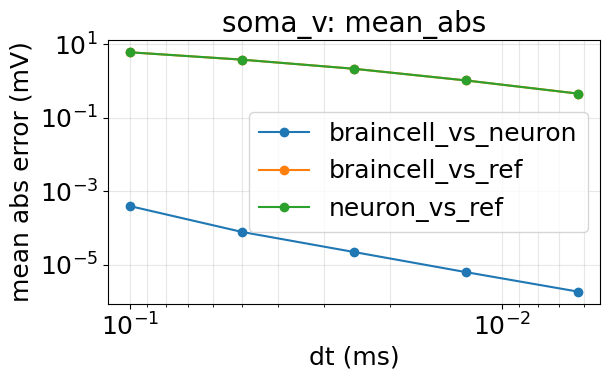

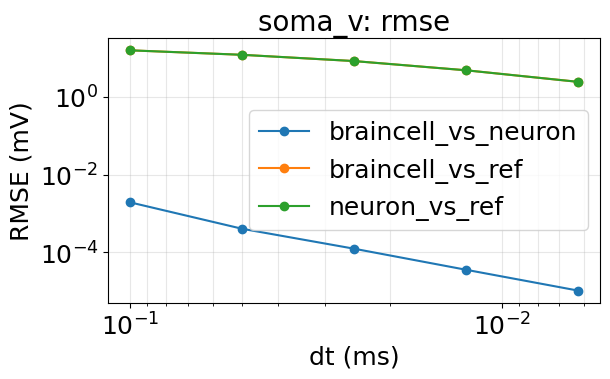

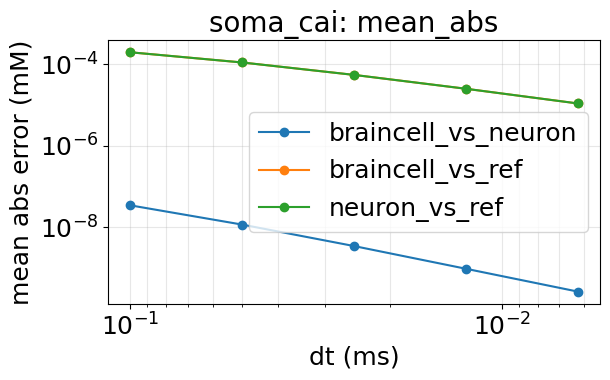

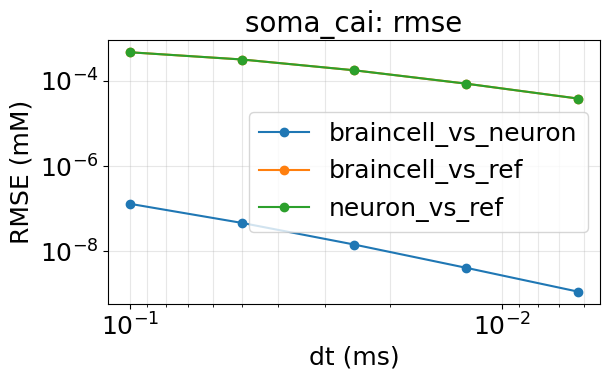

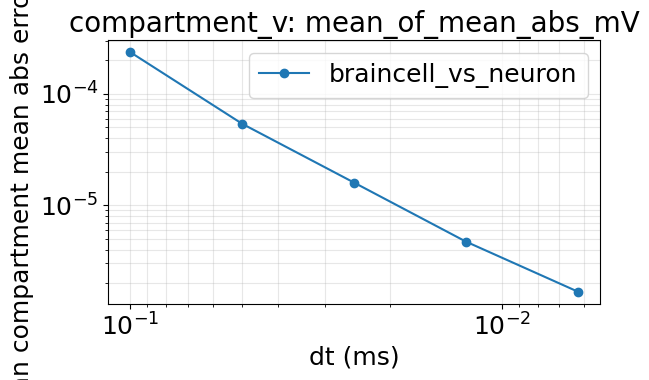

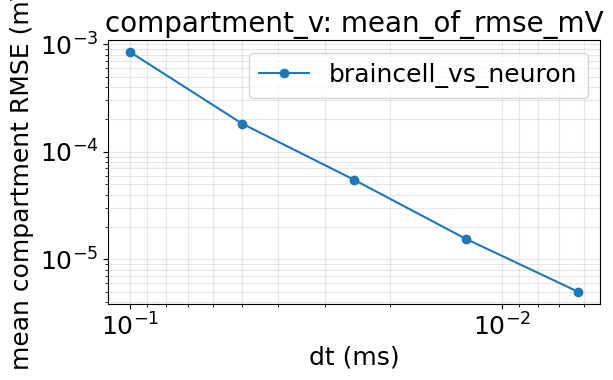

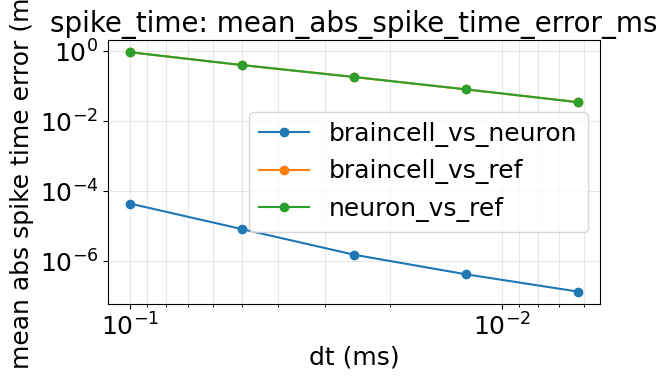

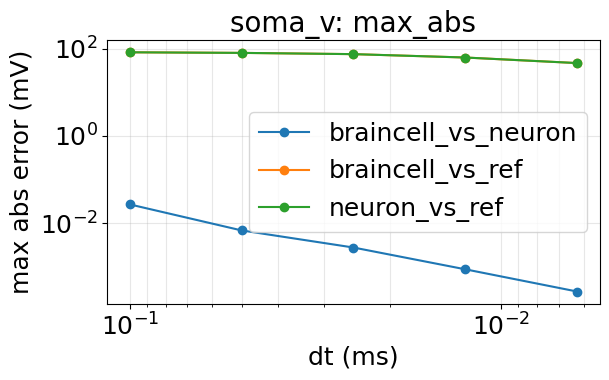

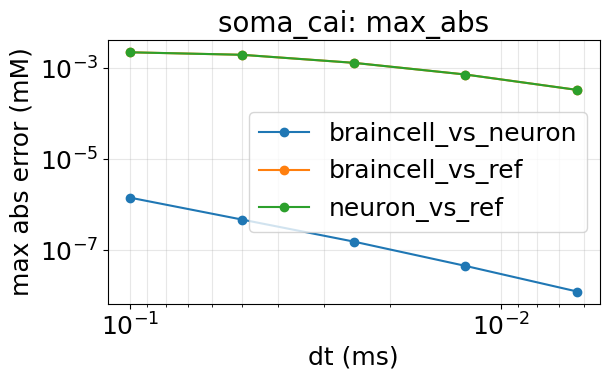

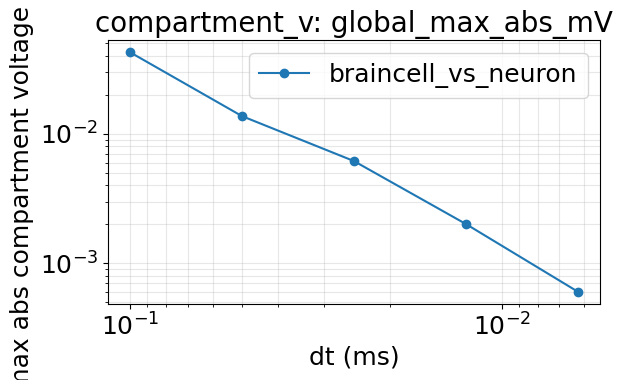

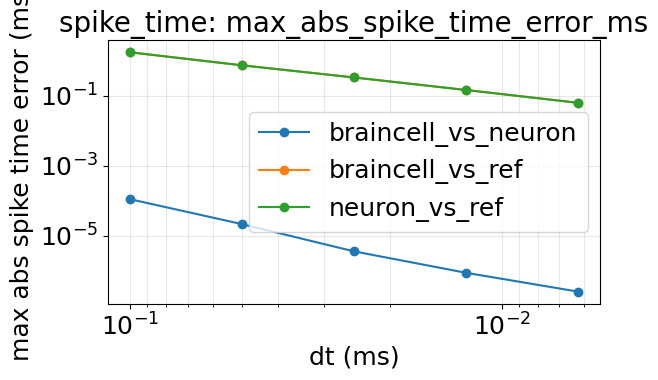

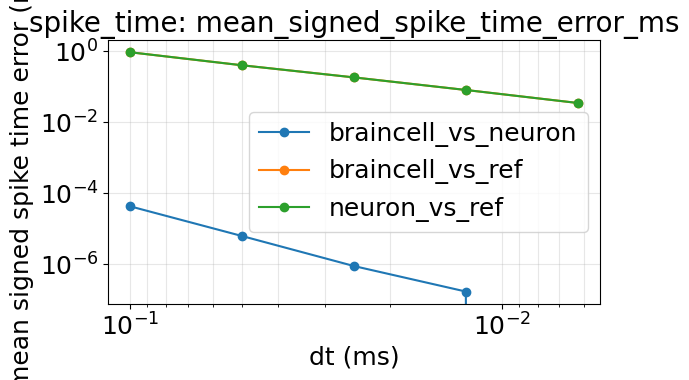

In [9]:
import matplotlib.pyplot as plt

# ========== 全局字体设置 ==========
plt.rcParams.update({
    'font.size': 20,          # 基础字体大小
    'axes.titlesize': 20,     # 子图标题（与基础保持一致）
    'axes.labelsize': 18,     # 坐标轴标签
    'xtick.labelsize': 18,    # X轴刻度
    'ytick.labelsize': 18,    # Y轴刻度
    'legend.fontsize': 18,    # 图例
    'figure.titlesize': 16,   # 总图标题
})
# =================================
def save_outputs(runs: dict[str, dict[str, Any]], summary_df: pd.DataFrame, orders_df: pd.DataFrame) -> None:
    config = {
        "smoke_mode": SMOKE_MODE,
        "duration_ms": DURATION_MS,
        "delay_ms": DELAY_MS,
        "stim_dur_ms": STIM_DUR_MS,
        "amp_nA": AMP_NA,
        "temp_C": TEMP_C,
        "v_init_mV": V_INIT_MV,
        "dt_list_ms": DT_LIST_MS,
        "ref_dt_ms": REF_DT_MS,
        "reference_scope": REFERENCE_SCOPE,
        "braincell_neuron_scope": BRAINCELL_NEURON_SCOPE,
        "selected_compartments": SELECTED_COMPARTMENTS,
        "spike_threshold_mV": SPIKE_THRESHOLD_MV,
        "frozen_ghk": FROZEN_GHK,
        "toggles": toggles_to_dict(TOGGLES),
    }
    (OUTPUT_DIR / "config.json").write_text(json.dumps(config, indent=2, sort_keys=True))
    summary_df.to_csv(OUTPUT_DIR / "summary.csv", index=False)
    orders_df.to_csv(OUTPUT_DIR / "orders.csv", index=False)
    metric_payload = summary_df.to_dict(orient="records")
    (OUTPUT_DIR / "metrics.json").write_text(json.dumps(metric_payload, indent=2, sort_keys=True))


def plot_convergence(summary_df: pd.DataFrame, metric: str, error_column: str, *, ylabel: str | None = None, save: bool = True):
    if error_column not in summary_df.columns:
        print("no column", error_column)
        return None
    data = summary_df[(summary_df["metric"] == metric) & summary_df[error_column].notna()].copy()
    if data.empty:
        print("no data for", metric, error_column)
        return None
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    for comparison, group in data.groupby("comparison"):
        g = group.sort_values("dt_ms")
        ax.loglog(g["dt_ms"], g[error_column], marker="o", label=comparison)
    ax.invert_xaxis()
    unit = data["unit"].iloc[0]
    ax.set_xlabel("dt (ms)")
    ax.set_ylabel(ylabel or f"{error_column} ({unit})")
    ax.set_title(f"{metric}: {error_column}")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if save:
        fig.savefig(OUTPUT_DIR / f"{metric}_{error_column}_convergence.png", dpi=300)
    return fig, ax


save_outputs(runs, summary_df, orders_df)
plot_convergence(summary_df, "soma_v", "mean_abs", ylabel="mean abs error (mV)")
plot_convergence(summary_df, "soma_v", "rmse", ylabel="RMSE (mV)")
plot_convergence(summary_df, "soma_cai", "mean_abs", ylabel="mean abs error (mM)")
plot_convergence(summary_df, "soma_cai", "rmse", ylabel="RMSE (mM)")
plot_convergence(summary_df, "compartment_v", "mean_of_mean_abs_mV", ylabel="mean compartment mean abs error (mV)")
plot_convergence(summary_df, "compartment_v", "mean_of_rmse_mV", ylabel="mean compartment RMSE (mV)")
plot_convergence(summary_df, "spike_time", "mean_abs_spike_time_error_ms", ylabel="mean abs spike time error (ms)")

plot_convergence(summary_df, "soma_v", "max_abs", ylabel="max abs error (mV)")
plot_convergence(summary_df, "soma_cai", "max_abs", ylabel="max abs error (mM)")
plot_convergence(summary_df, "compartment_v", "global_max_abs_mV", ylabel="global max abs compartment voltage error (mV)")
plot_convergence(summary_df, "spike_time", "max_abs_spike_time_error_ms", ylabel="max abs spike time error (ms)")
plot_convergence(summary_df, "spike_time", "mean_signed_spike_time_error_ms", ylabel="mean signed spike time error (ms)")
print("saved outputs to", OUTPUT_DIR)


(<Figure size 750x420 with 1 Axes>,
 <Axes: xlabel='time (ms)', ylabel='soma_v (mV)'>)

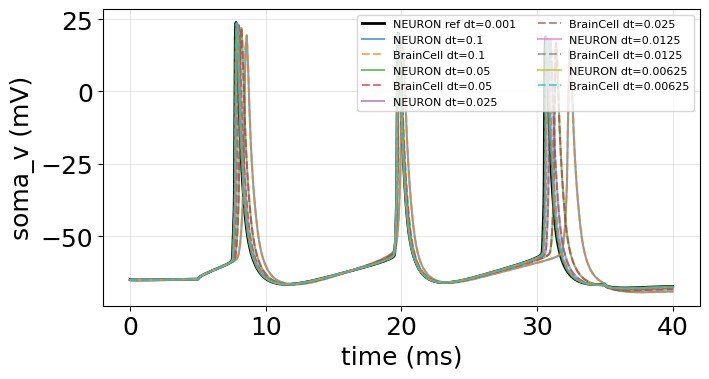

In [10]:

def plot_trace_overlay(runs: dict[str, dict[str, Any]], metric: str = "soma_v"):
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ref = runs["ref_neuron"]
    ax.plot(ref["time_ms"], ref[metric], label=f"NEURON ref dt={REF_DT_MS:g}", lw=2.0, color="black")
    for dt_ms in DT_LIST_MS:
        n = runs[f"neuron_{dt_ms:g}"]
        b = runs[f"braincell_{dt_ms:g}"]
        ax.plot(n["time_ms"], n[metric], label=f"NEURON dt={dt_ms:g}", alpha=0.65)
        ax.plot(b["time_ms"], b[metric], label=f"BrainCell dt={dt_ms:g}", alpha=0.65, linestyle="--")
    ax.set_xlabel("time (ms)")
    ax.set_ylabel(f"{metric} ({METRIC_UNITS.get(metric, '')})")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{metric}_trace_overlay.png", dpi=300)
    return fig, ax


plot_trace_overlay(runs, "soma_v")
